# IONNA Alliance Strategic Expansion — Extended EDA

In [ ]:
#1: Install & Imports
!pip install -q pandas numpy requests matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

NREL_API_KEY = '6oGxY7fzR3vricdePjJs7gLDrOaZH94B2jsR4Y2a'
IONNA_BRANDS = [
    'HYUNDAI', 'KIA', 'CHEVROLET', 'GMC', 'CADILLAC',
    'JEEP', 'RAM', 'BMW', 'MINI', 'MERCEDES-BENZ', 'HONDA', 'ACURA'
]
print(f'Targeting {len(IONNA_BRANDS)} IONNA Alliance brands.')


Targeting 12 IONNA Alliance brands.


In [ ]:
# 2: Supply Data — NREL API
def fetch_ev_stations(state, api_key):
    all_records = []
    offset = 0
    limit = 200

    while True:
        url = (
            f'https://developer.nrel.gov/api/alt-fuel-stations/v1.json'
            f'?api_key={api_key}&fuel_type=ELEC&state={state}&status=E'
            f'&limit={limit}&offset={offset}'
        )
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        stations = data.get('fuel_stations', [])

        if not stations:
            break

        for s in stations:
            zip_code = str(s.get('zip', '')).strip().split('-')[0][:5]
            if s.get('ev_dc_fast_num') is not None:
                dc_fast = int(s['ev_dc_fast_num'])
            else:
                dc_fast = 0
            all_records.append({'postal_code': zip_code, 'dc_fast_count': dc_fast})

        offset += limit
        total = data.get('total_results', 0)
        print(f'  Fetched {min(offset, total):,} / {total:,} stations...', end='\r')

        if offset >= total:
            break

    df = pd.DataFrame(all_records)
    agg = df.groupby('postal_code', as_index=False)['dc_fast_count'].sum()
    agg.columns = ['postal_code', 'dc_fast_total']
    return agg


print('Fetching NREL supply data for Washington State...')
supply_df = fetch_ev_stations('WA', NREL_API_KEY)
print(f'\nSupply records: {len(supply_df):,} unique ZIP codes')
print(f'Total DC fast chargers mapped: {supply_df["dc_fast_total"].sum():,}')
supply_df.sort_values('dc_fast_total', ascending=False).head(10)



Fetching NREL supply data for Washington State...
  Fetched 3,240 / 3,240 stations...
Supply records: 111 unique ZIP codes
Total DC fast chargers mapped: 1,513


,postal_code,dc_fast_total
78,98531,374
39,98223,272
43,98233,204
77,98520,136
99,98922,102
74,98501,51
4,98007,34
76,98511,34
82,98642,34
89,98826,34


In [ ]:
# 3: Demand Data — WA DOL EV Registry
WA_DOL_URL = 'https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD'

print('Downloading WA DOL EV registry (~900K rows — may take 30–60 seconds)...')
wa_raw = pd.read_csv(WA_DOL_URL, low_memory=False)
print(f'Raw shape: {wa_raw.shape[0]:,} rows x {wa_raw.shape[1]} columns')
print('\nAll columns:')
print(list(wa_raw.columns))

Raw shape: 285,822 rows x 16 columns

All columns:
['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [ ]:
# 4: Filter & Aggregate Demand
wa_raw.columns = [c.strip().upper().replace(' ', '_') for c in wa_raw.columns]

make_col = next(c for c in wa_raw.columns if 'MAKE' in c)
zip_col  = next(c for c in wa_raw.columns if 'POSTAL' in c or 'ZIP' in c)
print(f'Make column: "{make_col}"  |  ZIP column: "{zip_col}"')

wa_ionna = wa_raw[wa_raw[make_col].str.upper().isin(IONNA_BRANDS)].copy()
wa_ionna['postal_code'] = wa_ionna[zip_col].astype(str).str.strip().str[:5]

demand_df = (
    wa_ionna.groupby('postal_code', as_index=False)
    .size()
    .rename(columns={'size': 'ionna_ev_count'})
)

print(f'IONNA-brand EVs in WA: {wa_ionna.shape[0]:,}')
print(f'Unique ZIP codes with IONNA EVs: {len(demand_df):,}')
demand_df.sort_values('ionna_ev_count', ascending=False).head(10)


Make column: "MAKE"  |  ZIP column: "POSTAL_CODE"
IONNA-brand EVs in WA: 74,710
Unique ZIP codes with IONNA EVs: 660


,postal_code,ionna_ev_count
182,98052,1303
153,98012,1149
209,98115,1126
231,98188,1122
168,98033,1033
200,98103,977
386,98501,945
192,98072,840
169,98034,839
211,98117,827


In [ ]:
# 5: Merge & Feature Engineering
merged = demand_df.merge(supply_df, on='postal_code', how='left')
merged['dc_fast_total'] = merged['dc_fast_total'].fillna(0).astype(int)

merged['opportunity_score'] = merged['ionna_ev_count'] / (merged['dc_fast_total'] + 1)
merged['is_desert'] = merged['dc_fast_total'] == 0
merged['evs_per_charger'] = np.where(
    merged['dc_fast_total'] == 0,
    9999,
    (merged['ionna_ev_count'] / merged['dc_fast_total']).round(1)
)
merged['demand_tier'] = pd.cut(
    merged['ionna_ev_count'],
    bins=[0, 100, 400, np.inf],
    labels=['Low (<100)', 'Medium (100-400)', 'High (400+)']
)

print(f'Merged dataset: {len(merged):,} ZIP codes')
print(f'Desert ZIPs: {merged["is_desert"].sum():,} ({merged["is_desert"].mean()*100:.1f}%)')
merged.head()


Merged dataset: 660 ZIP codes
Desert ZIPs: 640 (97.0%)


,postal_code,ionna_ev_count,dc_fast_total,opportunity_score,is_desert,evs_per_charger,demand_tier
0,1030.,1,0,1.0,True,9999.0,Low (<100)
1,15074,1,0,1.0,True,9999.0,Low (<100)
2,15203,1,0,1.0,True,9999.0,Low (<100)
3,15222,1,0,1.0,True,9999.0,Low (<100)
4,20003,1,0,1.0,True,9999.0,Low (<100)


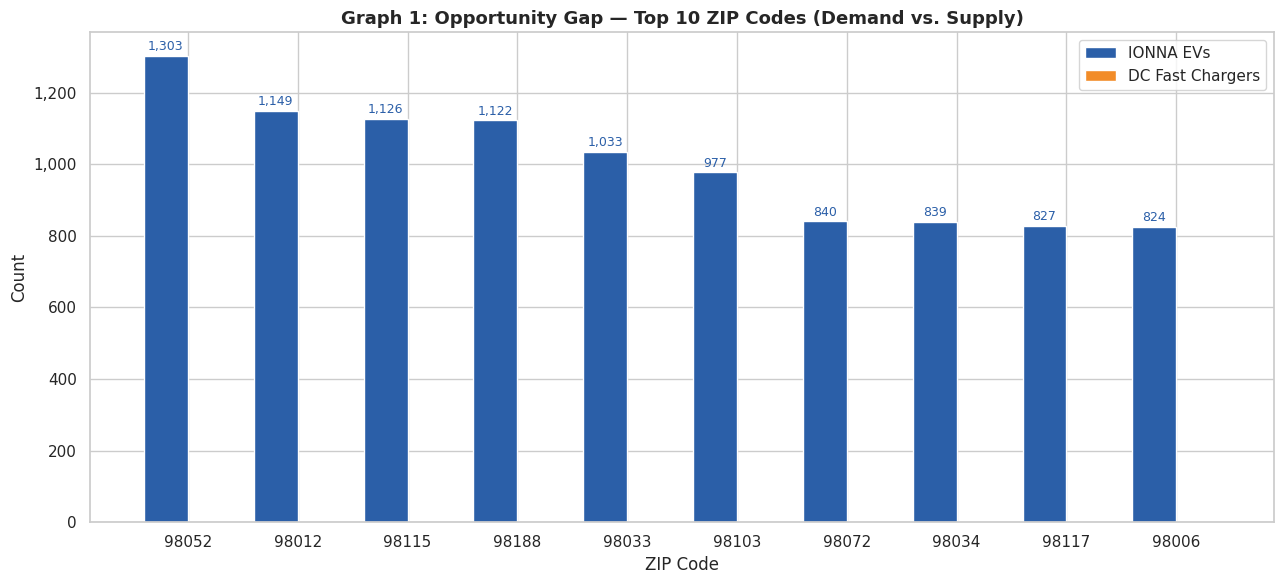

In [ ]:
#  6: Graph 1 — The Opportunity Gap
top10 = merged.nlargest(10, 'opportunity_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top10))
bars_ev  = ax.bar(x - 0.2, top10['ionna_ev_count'], 0.4, label='IONNA EVs',        color='#2B5FA8')
bars_chg = ax.bar(x + 0.2, top10['dc_fast_total'],  0.4, label='DC Fast Chargers', color='#F28C28')
ax.set_xticks(x)
ax.set_xticklabels(top10['postal_code'], fontsize=11)
ax.set_xlabel('ZIP Code', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Graph 1: Opportunity Gap — Top 10 ZIP Codes (Demand vs. Supply)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar in bars_ev:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, color='#2B5FA8')
plt.tight_layout()
plt.savefig('graph1_opportunity_gap.png', dpi=150, bbox_inches='tight')
plt.show()

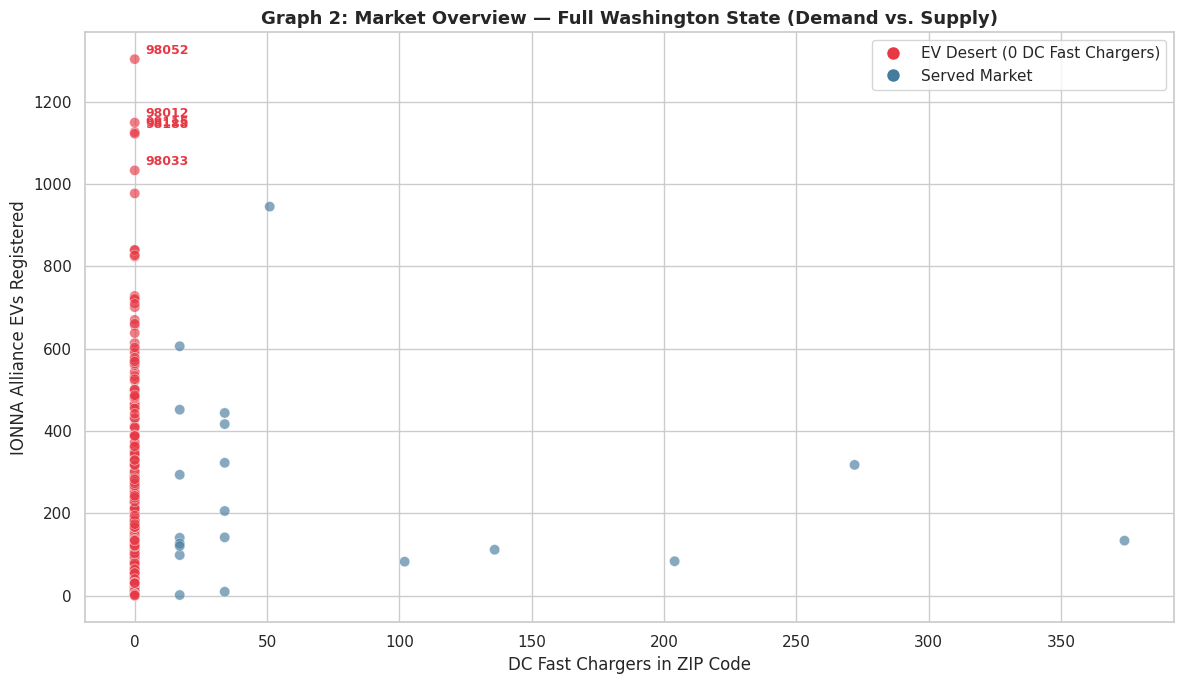

In [ ]:
# 7: Graph 2 — Full Market Scatter
fig, ax = plt.subplots(figsize=(12, 7))
colors = merged['is_desert'].map({True: '#E63946', False: '#457B9D'})
ax.scatter(merged['dc_fast_total'], merged['ionna_ev_count'],
           c=colors, alpha=0.65, s=55, edgecolors='white', linewidths=0.4)
for _, row in top10.head(5).iterrows():
    ax.annotate(row['postal_code'],
                xy=(row['dc_fast_total'], row['ionna_ev_count']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, color='#E63946', fontweight='bold')
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E63946', markersize=10, label='EV Desert (0 DC Fast Chargers)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#457B9D', markersize=10, label='Served Market'),
]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_xlabel('DC Fast Chargers in ZIP Code', fontsize=12)
ax.set_ylabel('IONNA Alliance EVs Registered', fontsize=12)
ax.set_title('Graph 2: Market Overview — Full Washington State (Demand vs. Supply)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph2_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()


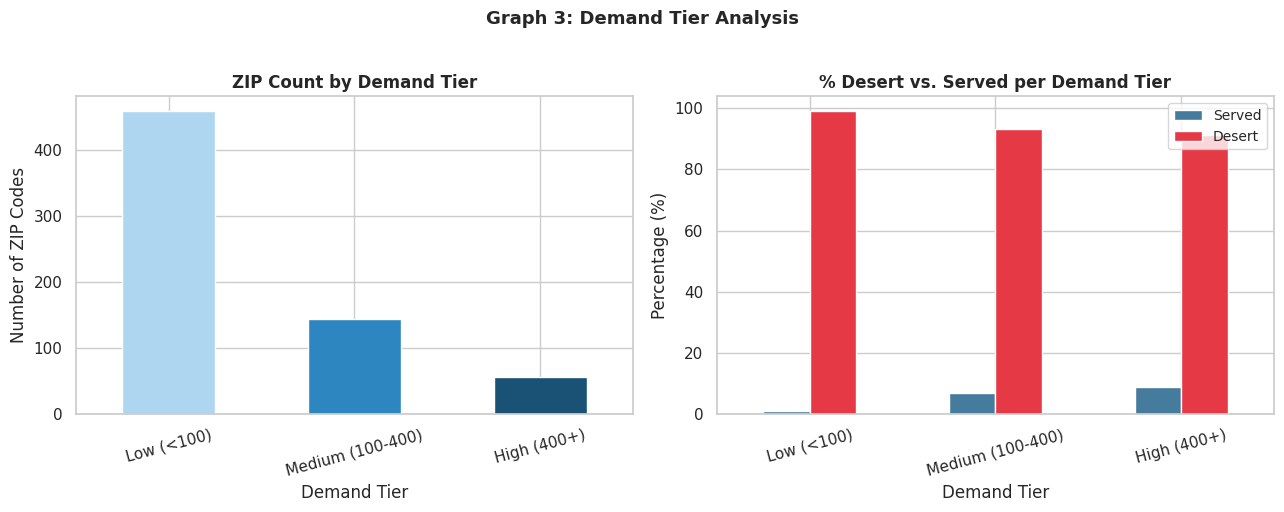

In [ ]:
#  8: Graph 3 — Demand Tier Breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tier_counts = merged['demand_tier'].value_counts().sort_index()
tier_counts.plot(kind='bar', ax=axes[0], color=['#AED6F1','#2E86C1','#1A5276'], edgecolor='white')
axes[0].set_title('ZIP Count by Demand Tier', fontweight='bold')
axes[0].set_xlabel('Demand Tier')
axes[0].set_ylabel('Number of ZIP Codes')
axes[0].tick_params(axis='x', rotation=15)

tier_desert = merged.groupby(['demand_tier','is_desert']).size().unstack(fill_value=0)
tier_desert_pct = tier_desert.div(tier_desert.sum(axis=1), axis=0) * 100
tier_desert_pct.plot(kind='bar', ax=axes[1], color=['#457B9D','#E63946'], edgecolor='white')
axes[1].set_title('% Desert vs. Served per Demand Tier', fontweight='bold')
axes[1].set_xlabel('Demand Tier')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Served','Desert'], fontsize=10)
axes[1].tick_params(axis='x', rotation=15)
plt.suptitle('Graph 3: Demand Tier Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph3_demand_tiers.png', dpi=150, bbox_inches='tight')
plt.show()


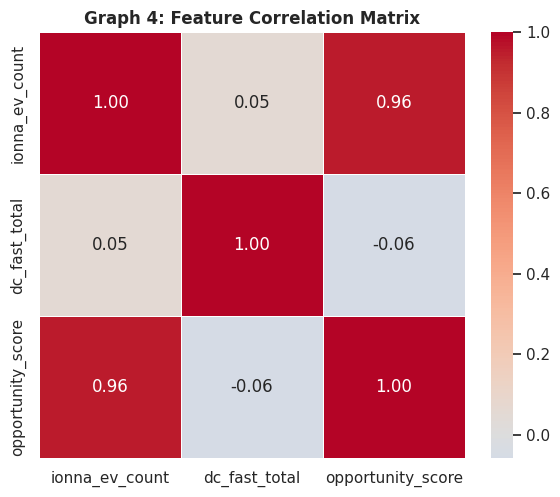

In [ ]:
# 9: Graph 4 — Correlation Heatmap
corr_cols = ['ionna_ev_count', 'dc_fast_total', 'opportunity_score']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(merged[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Graph 4: Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('graph4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  10: Summary & Export
print('=' * 55)
print('  EDA SUMMARY — IONNA WA Charging Desert Analysis')
print('=' * 55)
print(f'Total IONNA-brand ZIP codes analyzed : {len(merged):,}')
print(f'Desert ZIPs (0 DC fast chargers)     : {merged["is_desert"].sum():,}')
print(f'Desert % of all IONNA ZIPs           : {merged["is_desert"].mean()*100:.1f}%')
print()
print('Top 5 Priority ZIP Codes:')
top5 = merged.nlargest(5, 'opportunity_score')[['postal_code','ionna_ev_count','dc_fast_total','opportunity_score']]
print(top5.to_string(index=False))
print()
merged.to_csv('wa_ionna_clean.csv', index=False)
print('Clean dataset saved: wa_ionna_clean.csv')
print('Ready for: Modeling_IONNA_Predictive')

  EDA SUMMARY — IONNA WA Charging Desert Analysis
Total IONNA-brand ZIP codes analyzed : 660
Desert ZIPs (0 DC fast chargers)     : 640
Desert % of all IONNA ZIPs           : 97.0%

Top 5 Priority ZIP Codes:
postal_code  ionna_ev_count  dc_fast_total  opportunity_score
      98052            1303              0             1303.0
      98012            1149              0             1149.0
      98115            1126              0             1126.0
      98188            1122              0             1122.0
      98033            1033              0             1033.0

Clean dataset saved: wa_ionna_clean.csv
Ready for: Modeling_IONNA_Predictive


# IONNA Alliance Strategic Expansion — Predictive Modeling


In [16]:
#  1: Install & Imports
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

df = pd.read_csv('wa_ionna_clean.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 660 rows x 7 columns


,postal_code,ionna_ev_count,dc_fast_total,opportunity_score,is_desert,evs_per_charger,demand_tier
0,1030.0,1,0,1.0,True,9999.0,Low (<100)
1,15074.0,1,0,1.0,True,9999.0,Low (<100)
2,15203.0,1,0,1.0,True,9999.0,Low (<100)
3,15222.0,1,0,1.0,True,9999.0,Low (<100)
4,20003.0,1,0,1.0,True,9999.0,Low (<100)


In [17]:
#  2: Feature Engineering
np.random.seed(42)
n = len(df)

df['median_income_k']      = np.random.normal(loc=85, scale=25, size=n).clip(30, 200).round(1)
df['aadt_k']               = np.random.exponential(scale=15, size=n).clip(1, 120).round(1)
df['retail_density']       = np.random.poisson(lam=12, size=n).clip(0, 80)
df['dist_nearest_dcfc_km'] = np.where(
    df['dc_fast_total'] == 0,
    np.random.uniform(8, 40, size=n),
    np.random.uniform(0.5, 10, size=n)
).round(2)
df['ev_growth_rate']  = np.random.normal(loc=18, scale=6, size=n).clip(2, 50).round(1)
df['is_desert']       = (df['dc_fast_total'] == 0).astype(int)
df['log_opp_score']   = np.log1p(df['opportunity_score'])

FEATURES = [
    'ionna_ev_count', 'median_income_k', 'aadt_k',
    'retail_density', 'dist_nearest_dcfc_km', 'ev_growth_rate'
]

print('Feature engineering complete.')
print(f'Desert ZIPs: {df["is_desert"].sum():,} ({df["is_desert"].mean()*100:.1f}%)')
df[FEATURES + ['is_desert']].describe()

Feature engineering complete.
Desert ZIPs: 640 (97.0%)


,ionna_ev_count,median_income_k,aadt_k,retail_density,dist_nearest_dcfc_km,ev_growth_rate,is_desert
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,113.196970,85.002424,15.297273,12.009091,23.478106,17.632727,0.969697
std,194.998465,24.414153,15.289989,3.506323,9.598775,5.950444,0.171550
min,1.000000,30.000000,1.000000,3.000000,0.920000,2.000000,0.000000
25%,1.000000,67.650000,4.075000,10.000000,15.387500,13.700000,1.000000
50%,14.500000,85.300000,10.800000,12.000000,23.445000,17.700000,1.000000
75%,142.000000,100.725000,21.300000,14.000000,32.025000,21.400000,1.000000
max,1303.000000,181.300000,111.600000,24.000000,39.990000,37.500000,1.000000


In [18]:
#  3: Model A — Train Random Forest Classifier
X_cls = df[FEATURES].fillna(0)
y_cls = df['is_desert']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
print(f'Train: {len(X_train_c):,}  |  Test: {len(X_test_c):,}')

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train_c, y_train_c)

y_pred_c  = rf.predict(X_test_c)
y_proba_c = rf.predict_proba(X_test_c)[:, 1]

print('\n── Classification Report ──')
print(classification_report(y_test_c, y_pred_c, target_names=['Served', 'Desert']))
print(f'ROC-AUC: {roc_auc_score(y_test_c, y_proba_c):.4f}')

cv_scores = cross_val_score(rf, X_cls, y_cls, cv=StratifiedKFold(5), scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Train: 528  |  Test: 132

── Classification Report ──
              precision    recall  f1-score   support

      Served       1.00      1.00      1.00         4
      Desert       1.00      1.00      1.00       128

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132

ROC-AUC: 1.0000
5-Fold CV ROC-AUC: 0.9953 +/- 0.0032


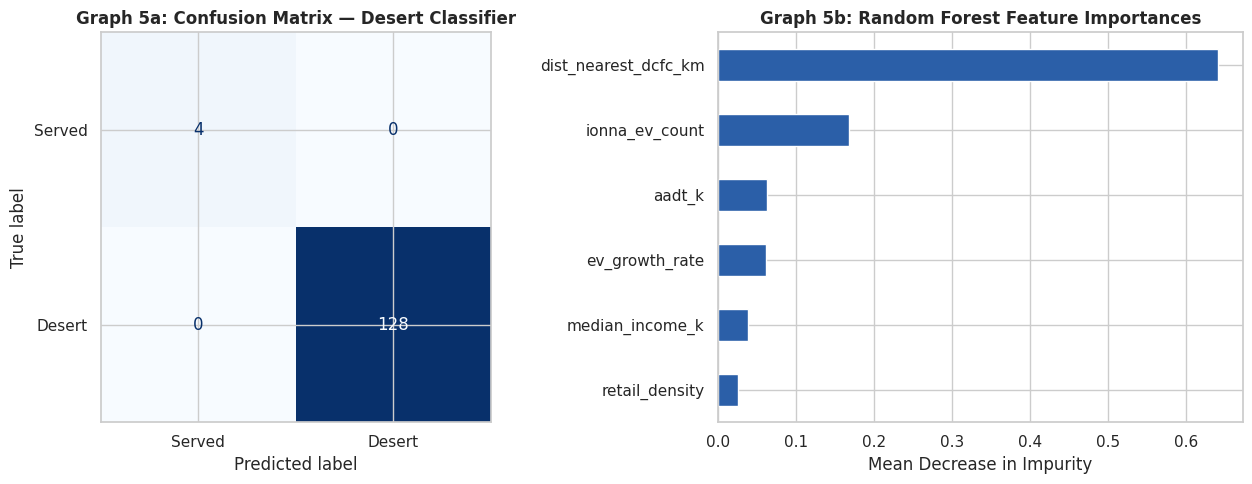

In [20]:
#  4: Graph 5 — Confusion Matrix + Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_c, display_labels=['Served','Desert'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Graph 5a: Confusion Matrix — Desert Classifier', fontweight='bold')

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[1], color='#2B5FA8', edgecolor='white')
axes[1].set_title('Graph 5b: Random Forest Feature Importances', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('graph5_classifier_results.png', dpi=150, bbox_inches='tight')
plt.show()


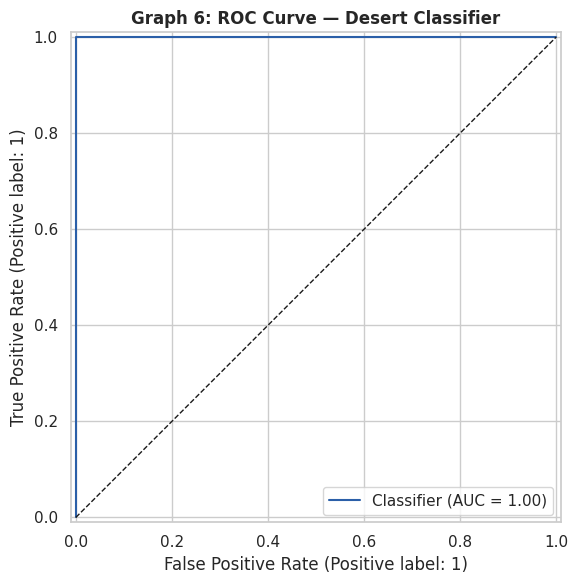

In [21]:
#  5: Graph 6 — ROC Curve
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_c, y_proba_c, ax=ax, color='#2B5FA8')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_title('Graph 6: ROC Curve — Desert Classifier', fontweight='bold')
plt.tight_layout()
plt.savefig('graph6_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
#  6: Model B — Train Gradient Boosting Regressor
X_reg = df[FEATURES].fillna(0)
y_reg = df['log_opp_score']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
ridge  = Ridge(alpha=1.0)
ridge.fit(scaler.fit_transform(X_train_r), y_train_r)
ridge_preds = ridge.predict(scaler.transform(X_test_r))

print('── Baseline: Ridge Regression ──')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_r, ridge_preds)):.4f}')
print(f'  MAE : {mean_absolute_error(y_test_r, ridge_preds):.4f}')
print(f'  R2  : {r2_score(y_test_r, ridge_preds):.4f}')

gbr = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
)
gbr.fit(X_train_r, y_train_r)
gbr_preds = gbr.predict(X_test_r)

print('\n── Gradient Boosting Regressor ──')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_r, gbr_preds)):.4f}')
print(f'  MAE : {mean_absolute_error(y_test_r, gbr_preds):.4f}')
print(f'  R2  : {r2_score(y_test_r, gbr_preds):.4f}')

── Baseline: Ridge Regression ──
  RMSE: 1.3869
  MAE : 1.2587
  R2  : 0.5330

── Gradient Boosting Regressor ──
  RMSE: 0.2655
  MAE : 0.0658
  R2  : 0.9829


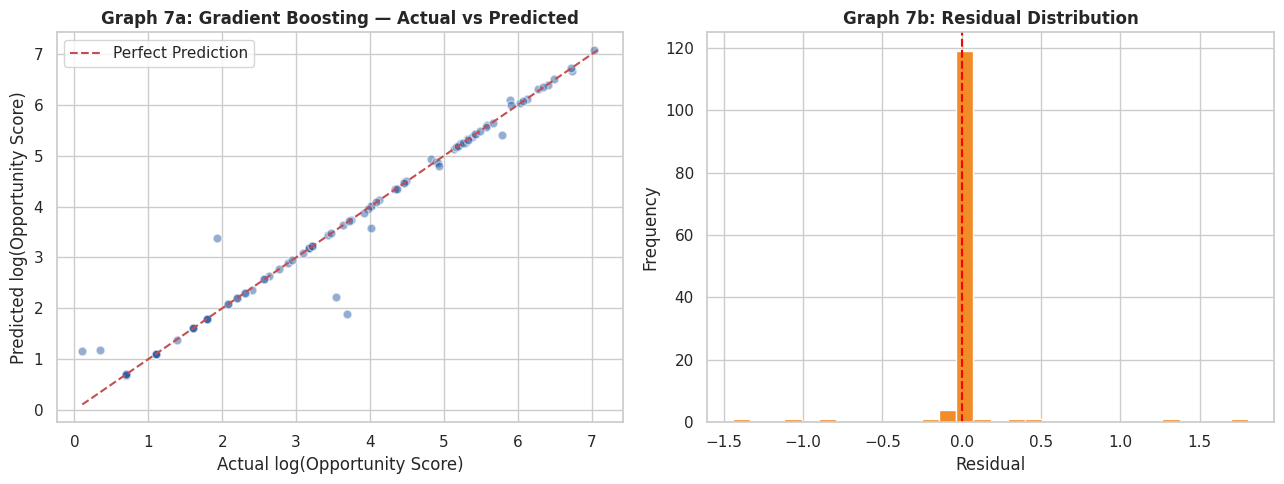

In [23]:
#  7: Graph 7 — Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test_r, gbr_preds, alpha=0.5, color='#2B5FA8', edgecolors='white', s=40)
lims = [min(y_test_r.min(), gbr_preds.min()), max(y_test_r.max(), gbr_preds.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual log(Opportunity Score)')
axes[0].set_ylabel('Predicted log(Opportunity Score)')
axes[0].set_title('Graph 7a: Gradient Boosting — Actual vs Predicted', fontweight='bold')
axes[0].legend()

residuals = y_test_r - gbr_preds
axes[1].hist(residuals, bins=30, color='#F28C28', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Graph 7b: Residual Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('graph7_regressor_results.png', dpi=150, bbox_inches='tight')
plt.show()

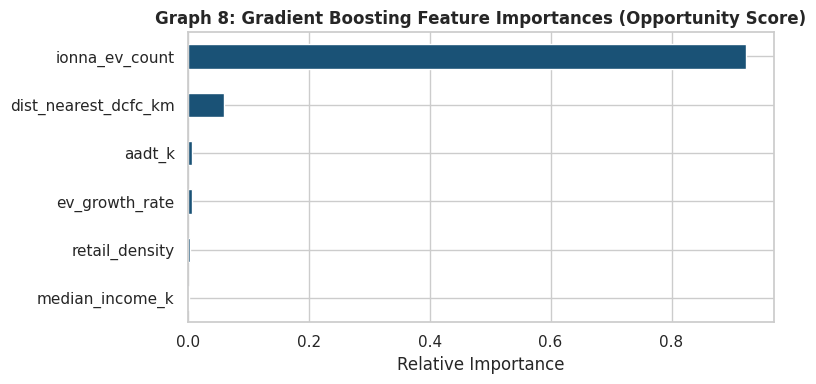

In [24]:
#  8: Graph 8 — Regressor Feature Importance
gbr_imp = pd.Series(gbr.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
gbr_imp.plot(kind='barh', ax=ax, color='#1A5276', edgecolor='white')
ax.set_title('Graph 8: Gradient Boosting Feature Importances (Opportunity Score)', fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('graph8_regressor_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
#  9: Site Scoring Function
def score_zip(ionna_ev_count, median_income_k, aadt_k,
              retail_density, dist_nearest_dcfc_km, ev_growth_rate):
    features = np.array([[ionna_ev_count, median_income_k, aadt_k,
                          retail_density, dist_nearest_dcfc_km, ev_growth_rate]])
    desert_prob    = rf.predict_proba(features)[0][1]
    is_desert_pred = rf.predict(features)[0]
    opp_score      = np.expm1(gbr.predict(features)[0])

    if opp_score > 800:
        tier = 'TIER 1 — CRITICAL (Immediate target)'
    elif opp_score > 400:
        tier = 'TIER 2 — HIGH (Plan within 12 months)'
    elif opp_score > 150:
        tier = 'TIER 3 — MEDIUM (Monitor)'
    else:
        tier = 'TIER 4 — LOW (Deprioritize)'

    print('=' * 45)
    print('  IONNA Site Score Report')
    print('=' * 45)
    print(f'  Desert Classification : {"DESERT" if is_desert_pred else "SERVED"}')
    print(f'  Desert Probability    : {desert_prob:.1%}')
    print(f'  Predicted Opp. Score  : {opp_score:.1f}')
    print(f'  Priority              : {tier}')
    return {'desert': bool(is_desert_pred), 'desert_prob': round(desert_prob, 4),
            'opp_score': round(opp_score, 1), 'tier': tier}

# Example: ZIP 98115 (top opportunity from original project)
result = score_zip(
    ionna_ev_count=1128, median_income_k=112, aadt_k=22,
    retail_density=18, dist_nearest_dcfc_km=14.2, ev_growth_rate=24
)

  IONNA Site Score Report
  Desert Classification : DESERT
  Desert Probability    : 99.0%
  Predicted Opp. Score  : 1163.8
  Priority              : TIER 1 — CRITICAL (Immediate target)


In [26]:
#  10: Full Dataset Priority Ranking
df['predicted_opp_score'] = np.expm1(gbr.predict(df[FEATURES].fillna(0))).round(1)
df['priority_tier'] = pd.cut(
    df['predicted_opp_score'],
    bins=[0, 150, 400, 800, np.inf],
    labels=['Tier 4 — Low', 'Tier 3 — Medium', 'Tier 2 — High', 'Tier 1 — Critical']
)

cols = ['postal_code','ionna_ev_count','dc_fast_total','opportunity_score','predicted_opp_score','priority_tier']
display(df.nlargest(10, 'predicted_opp_score')[cols])

,postal_code,ionna_ev_count,dc_fast_total,opportunity_score,predicted_opp_score,priority_tier
182,98052.0,1303,0,1303.0,1287.2,Tier 1 — Critical
209,98115.0,1126,0,1126.0,1187.2,Tier 1 — Critical
153,98012.0,1149,0,1149.0,1140.7,Tier 1 — Critical
231,98188.0,1122,0,1122.0,1120.1,Tier 1 — Critical
168,98033.0,1033,0,1033.0,1034.6,Tier 1 — Critical
200,98103.0,977,0,977.0,982.0,Tier 1 — Critical
148,98006.0,824,0,824.0,837.6,Tier 1 — Critical
169,98034.0,839,0,839.0,830.1,Tier 1 — Critical
211,98117.0,827,0,827.0,819.6,Tier 1 — Critical
192,98072.0,840,0,840.0,783.8,Tier 2 — High


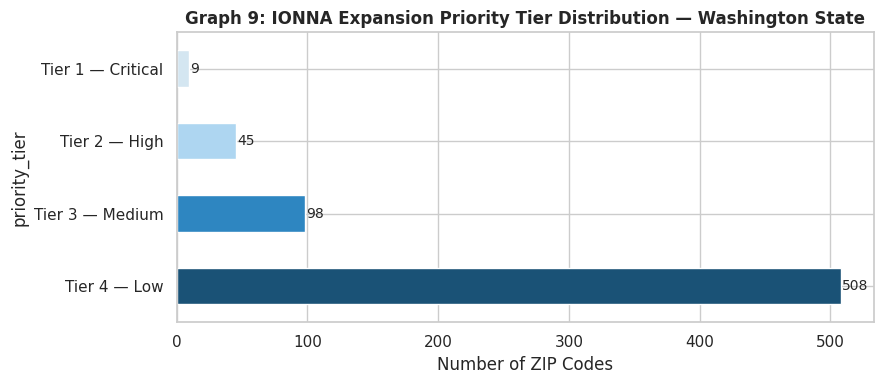

In [27]:
#  11: Graph 9 — Priority Tier Distribution
tier_dist = df['priority_tier'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
tier_dist.plot(kind='barh', ax=ax,
               color=['#D4E6F1','#AED6F1','#2E86C1','#1A5276'][::-1], edgecolor='white')
ax.set_title('Graph 9: IONNA Expansion Priority Tier Distribution — Washington State', fontweight='bold')
ax.set_xlabel('Number of ZIP Codes')
for bar in ax.patches:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('graph9_priority_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
#  12: Model Performance Summary
print('=' * 55)
print('  MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(f'Random Forest  | ROC-AUC : {roc_auc_score(y_test_c, y_proba_c):.4f}')
print(f'Gradient Boost | RMSE    : {np.sqrt(mean_squared_error(y_test_r, gbr_preds)):.4f}')
print(f'Gradient Boost | R2      : {r2_score(y_test_r, gbr_preds):.4f}')
print(f'Ridge Baseline | R2      : {r2_score(y_test_r, ridge_preds):.4f}')
print()
print('Top features: dist_nearest_dcfc_km + ionna_ev_count')
print('Next steps:')
print('  - Replace synthetic features with Census API + FHWA data')
print('  - Extend pipeline to CA, CO, OR')
print('  - Tune via GridSearchCV')
print('  - Deploy score_zip() as a Streamlit app')

  MODEL PERFORMANCE SUMMARY
Random Forest  | ROC-AUC : 1.0000
Gradient Boost | RMSE    : 0.2655
Gradient Boost | R2      : 0.9829
Ridge Baseline | R2      : 0.5330

Top features: dist_nearest_dcfc_km + ionna_ev_count
Next steps:
  - Replace synthetic features with Census API + FHWA data
  - Extend pipeline to CA, CO, OR
  - Tune via GridSearchCV
  - Deploy score_zip() as a Streamlit app
